<a href="https://colab.research.google.com/github/rinlopable/PCD_Assignment02/blob/main/PCD_Assignment02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCD_Assignment02

## Image Enhancement Using Pixel-Based and Spatial Filtering Methods

**Name:** Ni Wayan Regina Raytana Putri  
**Student ID:** 25/558695/PA/23481

## 1. Introduction

Image enhancement is used to improve image quality so that important details can be seen more clearly. Different image problems need different enhancement methods depending on how the image is degraded.

In this assignment, I will work with four different image problems: blur, excessive brightness, darkness, and low contrast. Each problem will use one image and one enhancement method. The result will be compared visually and using PSNR before and after enhancement.

## 2. Objectives

The objectives of this assignment are:

- To create four different image problems: blur, bright, dark, and low contrast.
- To apply an appropriate enhancement method for each problem.
- To compare the images before and after enhancement visually.
- To compare the PSNR values before and after enhancement using the original images as references.
- To analyze how effective each enhancement method is.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
repo_url = "https://github.com/rinlopable/PCD_Assignment02.git"
repo_path = "/content/PCD_Assignment02"

if os.path.exists(repo_path):
    %cd /content/PCD_Assignment02
    !git pull
else:
    %cd /content
    !git clone {repo_url}

/content
Cloning into 'PCD_Assignment02'...
remote: Enumerating objects: 155, done.
remote: Counting objects: 100% (155/155), done.
remote: Compressing objects: 100% (144/144), done.
remote: Total 155 (delta 54), reused 13 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (155/155), 13.39 MiB | 11.43 MiB/s, done.
Resolving deltas: 100% (54/54), done.


## 3. Problem 1 - Blurred Image

For the first problem, I intentionally blurred the original image using a Gaussian filter. Blurring reduces fine details and makes edges less clear.

To improve the blurred image, I applied a sharpening filter. Sharpening increases edge contrast so that details become more visible again.

Image shape: (675, 1200, 3)


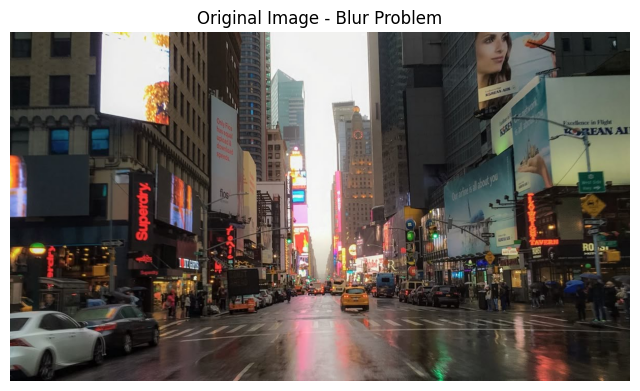

In [7]:
blur_path = "/content/PCD_Assignment02/images/original/original_blur.JPG"

original_blur = cv2.imread(blur_path)

print("Image shape:", original_blur.shape)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original_blur, cv2.COLOR_BGR2RGB))
plt.title("Original Image - Blur Problem")
plt.axis("off")
plt.show()

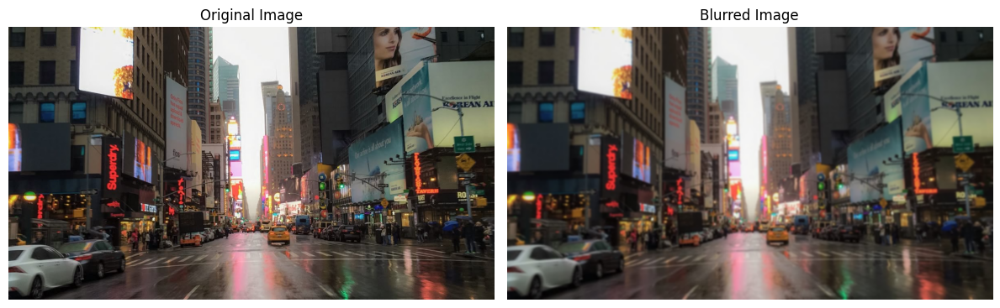

In [8]:
blurred_image = cv2.GaussianBlur(
    original_blur,
    (9, 9),
    2
)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_blur, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))
plt.title("Blurred Image")
plt.axis("off")

plt.tight_layout()
plt.show()

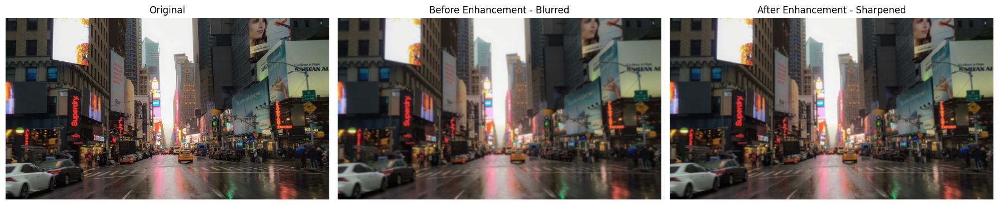

PSNR Before Enhancement : 26.88 dB
PSNR After Enhancement  : 27.89 dB


In [13]:
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened_image = cv2.filter2D(
    blurred_image,
    -1,
    sharpen_kernel
)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_blur, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))
plt.title("Before Enhancement - Blurred")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB))
plt.title("After Enhancement - Sharpened")
plt.axis("off")

plt.tight_layout()
plt.show()

psnr_blur_before = cv2.PSNR(original_blur, blurred_image)
psnr_blur_after = cv2.PSNR(original_blur, sharpened_image)

print(f"PSNR Before Enhancement : {psnr_blur_before:.2f} dB")
print(f"PSNR After Enhancement  : {psnr_blur_after:.2f} dB")

### Analysis

After applying the sharpening filter, the blurred image became slightly clearer, especially around the edges of buildings, vehicles, signs, and other small details.

The PSNR increased from 26.88 dB before enhancement to 27.89 dB after enhancement. The improvement is not very large because sharpening mainly emphasizes existing edges and cannot fully recover details that were lost during the blurring process. However, both the visual result and PSNR value show that the sharpened image is closer to the original image than the blurred version.

## 4. Problem 2 - Bright Image

For the second problem, I intentionally increased the brightness of the original image to create an overly bright image. When an image is too bright, some details can become less visible because many pixel values move toward the higher intensity range.

To improve the image, I applied Gamma Correction. A gamma value greater than 1 is used to reduce the brightness and bring the image closer to its original appearance.

Image shape: (800, 1200, 3)


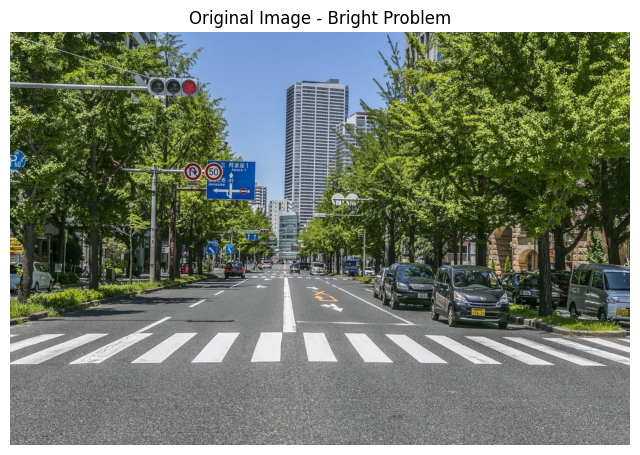

In [15]:
bright_path = "/content/PCD_Assignment02/images/original/original_bright.JPG"

original_bright = cv2.imread(bright_path)

print("Image shape:", original_bright.shape)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original_bright, cv2.COLOR_BGR2RGB))
plt.title("Original Image - Bright Problem")
plt.axis("off")
plt.show()

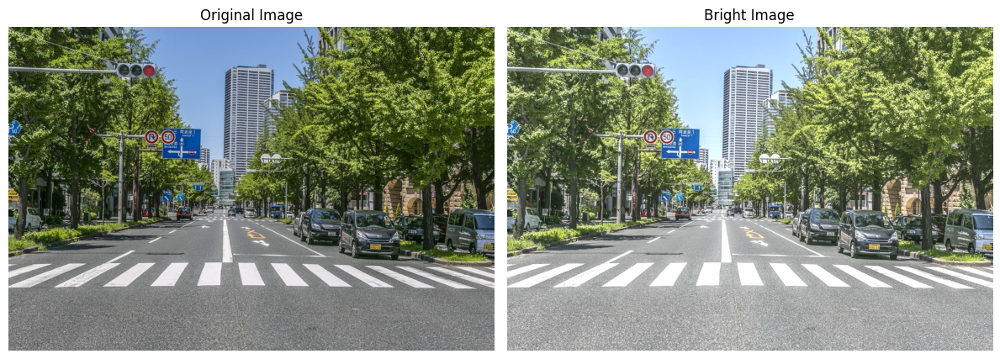

In [17]:
ycrcb = cv2.cvtColor(original_bright, cv2.COLOR_BGR2YCrCb)

y_channel = ycrcb[:, :, 0].astype(np.float32)

alpha = 1.2
beta = 20

bright_y = alpha * y_channel + beta
bright_y = np.clip(bright_y, 0, 255).astype(np.uint8)

ycrcb[:, :, 0] = bright_y

bright_image = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_bright, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(bright_image, cv2.COLOR_BGR2RGB))
plt.title("Bright Image")
plt.axis("off")

plt.tight_layout()
plt.show()

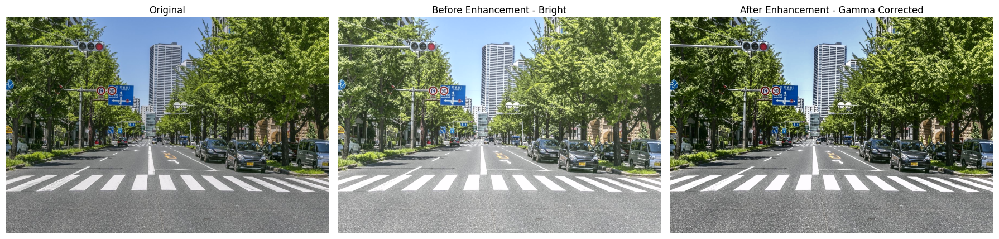

PSNR Before Enhancement : 16.13 dB
PSNR After Enhancement  : 23.51 dB
Improvement             : +7.38 dB


In [21]:
def gamma_correction(image, gamma):
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

    y_channel = ycrcb[:, :, 0].astype(np.float32) / 255.0

    corrected_y = np.power(y_channel, gamma) * 255.0
    corrected_y = np.clip(corrected_y, 0, 255).astype(np.uint8)

    ycrcb[:, :, 0] = corrected_y

    corrected_image = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

    return corrected_image

gamma = 1.6

corrected_bright = gamma_correction(bright_image, gamma)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_bright, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(bright_image, cv2.COLOR_BGR2RGB))
plt.title("Before Enhancement - Bright")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(corrected_bright, cv2.COLOR_BGR2RGB))
plt.title("After Enhancement - Gamma Corrected")
plt.axis("off")

plt.tight_layout()
plt.show()

psnr_bright_before = cv2.PSNR(original_bright, bright_image)
psnr_bright_after = cv2.PSNR(original_bright, corrected_bright)

print(f"PSNR Before Enhancement : {psnr_bright_before:.2f} dB")
print(f"PSNR After Enhancement  : {psnr_bright_after:.2f} dB")
print(f"Improvement             : {psnr_bright_after - psnr_bright_before:+.2f} dB")

### Analysis

After applying Gamma Correction, the overly bright image became closer to the original image. Some details that looked washed out in the bright image became clearer, especially around the trees, road, vehicles, and buildings.

The PSNR increased from 16.13 dB before enhancement to 23.51 dB after enhancement, giving an improvement of 7.38 dB. This shows that Gamma Correction successfully reduced the excessive brightness and produced an image that is more similar to the original reference image.

## 5. Problem 3 - Dark Image

For the third problem, I intentionally reduced the brightness of the original image to create a dark image. When the image becomes too dark, some details in the shadow areas become difficult to see.

To improve the dark image, I applied a Logarithmic Transformation. This transformation expands lower intensity values, making details in darker areas more visible.

Image shape: (490, 735, 3)


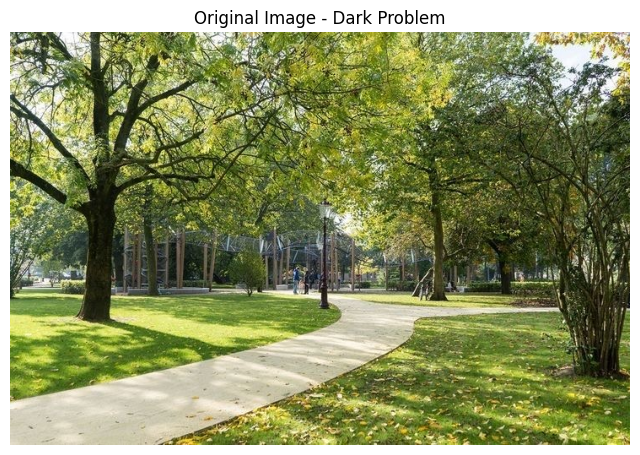

In [23]:
dark_path = "/content/PCD_Assignment02/images/original/original_dark.JPG"

original_dark = cv2.imread(dark_path)

print("Image shape:", original_dark.shape)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original_dark, cv2.COLOR_BGR2RGB))
plt.title("Original Image - Dark Problem")
plt.axis("off")
plt.show()

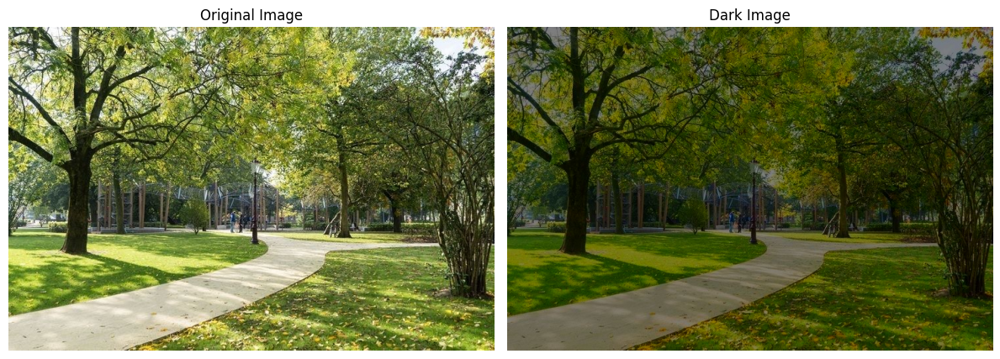

In [25]:
ycrcb = cv2.cvtColor(original_dark, cv2.COLOR_BGR2YCrCb)

y_channel = ycrcb[:, :, 0].astype(np.float32)

dark_factor = 0.5

dark_y = dark_factor * y_channel
dark_y = np.clip(dark_y, 0, 255).astype(np.uint8)

ycrcb[:, :, 0] = dark_y

dark_image = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_dark, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(dark_image, cv2.COLOR_BGR2RGB))
plt.title("Dark Image")
plt.axis("off")

plt.tight_layout()
plt.show()

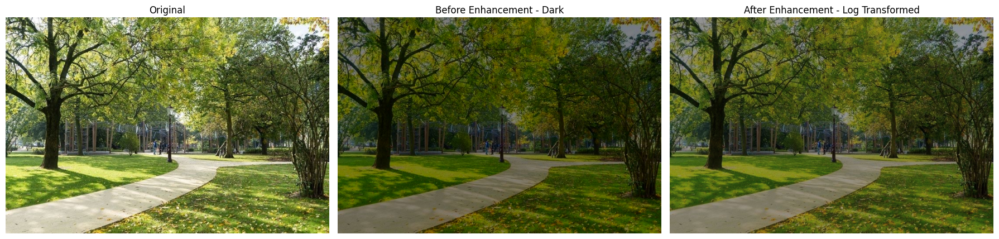

PSNR Before Enhancement : 11.63 dB
PSNR After Enhancement  : 13.97 dB
Improvement             : +2.34 dB


In [29]:
def log_transformation(image):
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

    y_channel = ycrcb[:, :, 0].astype(np.float32) / 255.0

    log_y = np.log1p(y_channel) / np.log(2.0)

    log_y = np.clip(log_y * 255.0, 0, 255).astype(np.uint8)

    ycrcb[:, :, 0] = log_y

    transformed_image = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

    return transformed_image

corrected_dark = log_transformation(dark_image)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_dark, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(dark_image, cv2.COLOR_BGR2RGB))
plt.title("Before Enhancement - Dark")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(corrected_dark, cv2.COLOR_BGR2RGB))
plt.title("After Enhancement - Log Transformed")
plt.axis("off")

plt.tight_layout()
plt.show()

psnr_dark_before = cv2.PSNR(original_dark, dark_image)
psnr_dark_after = cv2.PSNR(original_dark, corrected_dark)

print(f"PSNR Before Enhancement : {psnr_dark_before:.2f} dB")
print(f"PSNR After Enhancement  : {psnr_dark_after:.2f} dB")
print(f"Improvement             : {psnr_dark_after - psnr_dark_before:+.2f} dB")

### Analysis

After applying the Logarithmic Transformation, details in the darker areas became more visible, especially around the trees, grass, and pathway.

The PSNR increased from 11.63 dB before enhancement to 13.97 dB after enhancement, giving an improvement of 2.34 dB. The enhanced image is still slightly darker than the original image, since the Logarithmic Transformation does not directly reverse the darkening process. However, both the visual result and PSNR value show that the transformation successfully improved the dark image.

## 6. Problem 4 - Low-Contrast Image

For the fourth problem, I intentionally reduced the contrast of the original image. A low-contrast image has a smaller difference between dark and bright areas, which makes the image look flatter and less clear.

To improve the image, I applied Contrast Stretching. This method expands the intensity range so that darker and brighter areas become more distinguishable.

Image shape: (751, 1200, 3)


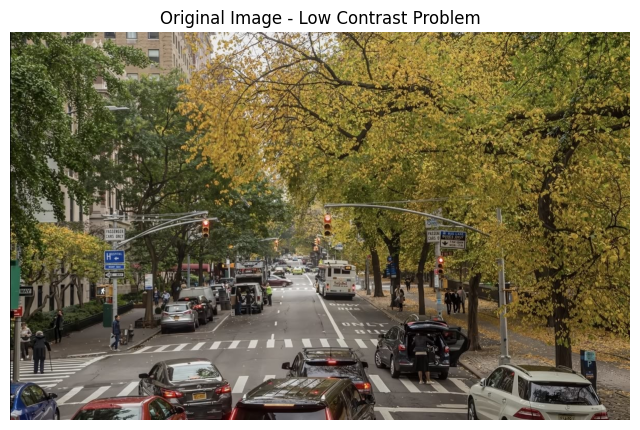

In [30]:
low_contrast_path = "/content/PCD_Assignment02/images/original/original_low_contrast.JPG"

original_low_contrast = cv2.imread(low_contrast_path)

print("Image shape:", original_low_contrast.shape)

plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(original_low_contrast, cv2.COLOR_BGR2RGB))
plt.title("Original Image - Low Contrast Problem")
plt.axis("off")
plt.show()

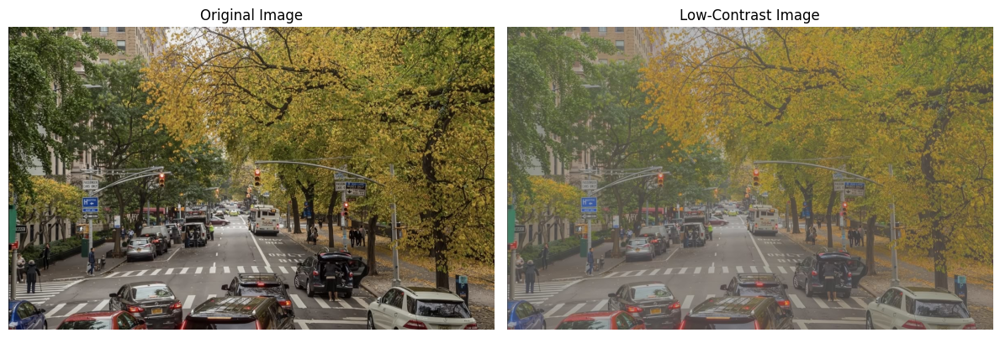

In [32]:
ycrcb = cv2.cvtColor(original_low_contrast, cv2.COLOR_BGR2YCrCb)

y_channel = ycrcb[:, :, 0].astype(np.float32)

alpha = 0.5
beta = 64

low_y = alpha * y_channel + beta
low_y = np.clip(low_y, 0, 255).astype(np.uint8)

ycrcb[:, :, 0] = low_y

low_contrast_image = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_low_contrast, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(low_contrast_image, cv2.COLOR_BGR2RGB))
plt.title("Low-Contrast Image")
plt.axis("off")

plt.tight_layout()
plt.show()

Contrast Stretching maps the minimum and maximum intensity values to a wider range.

**P_out = (P_in - Min) × (255 / (Max - Min))**

The enhancement is applied only to the Y (luminance) channel so that the contrast can be improved while preserving the color information.

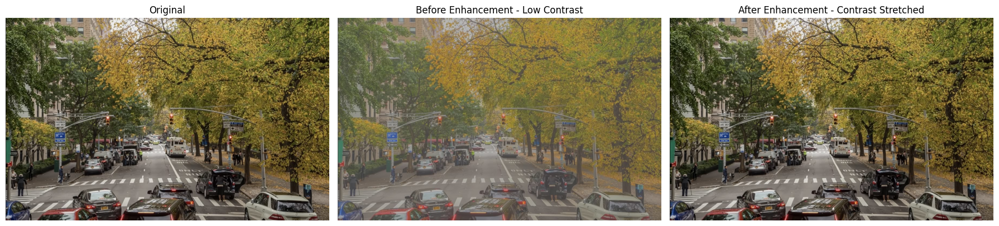

PSNR Before Enhancement : 19.09 dB
PSNR After Enhancement  : 50.86 dB
Improvement             : +31.77 dB


In [35]:
def contrast_stretching(image):
    ycrcb = cv2.cvtColor(image, cv2.COLOR_BGR2YCrCb)

    y_channel = ycrcb[:, :, 0]

    min_value = np.min(y_channel)
    max_value = np.max(y_channel)

    stretched_y = (y_channel - min_value) * (255.0 / (max_value - min_value))
    stretched_y = np.clip(stretched_y, 0, 255).astype(np.uint8)

    ycrcb[:, :, 0] = stretched_y

    stretched_image = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

    return stretched_image

corrected_low_contrast = contrast_stretching(low_contrast_image)

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(original_low_contrast, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(low_contrast_image, cv2.COLOR_BGR2RGB))
plt.title("Before Enhancement - Low Contrast")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(corrected_low_contrast, cv2.COLOR_BGR2RGB))
plt.title("After Enhancement - Contrast Stretched")
plt.axis("off")

plt.tight_layout()
plt.show()

psnr_low_before = cv2.PSNR(original_low_contrast, low_contrast_image)
psnr_low_after = cv2.PSNR(original_low_contrast, corrected_low_contrast)

print(f"PSNR Before Enhancement : {psnr_low_before:.2f} dB")
print(f"PSNR After Enhancement  : {psnr_low_after:.2f} dB")
print(f"Improvement             : {psnr_low_after - psnr_low_before:+.2f} dB")

### Analysis

After applying Contrast Stretching, the low-contrast image became much clearer. The difference between dark and bright areas increased, making details in the road, vehicles, buildings, and trees more visible.

The PSNR increased from 19.09 dB before enhancement to 50.86 dB after enhancement, giving an improvement of 31.77 dB. The very high PSNR value shows that the enhanced image became very close to the original reference image.

This large improvement is also related to how the low-contrast image was created. Since the contrast was reduced using a controlled linear transformation, Contrast Stretching was able to recover the intensity range very effectively.

## 7. Overall Comparison

After testing all four image problems, the PSNR values before and after enhancement can be compared to see how effective each method was.

In [36]:
problems = ["Blur", "Bright", "Dark", "Low Contrast"]

psnr_before = [
    psnr_blur_before,
    psnr_bright_before,
    psnr_dark_before,
    psnr_low_before
]

psnr_after = [
    psnr_blur_after,
    psnr_bright_after,
    psnr_dark_after,
    psnr_low_after
]

print("PSNR Comparison")
print("-" * 75)
print(f"{'Problem':<15}{'Before (dB)':<18}{'After (dB)':<18}{'Improvement':<15}")
print("-" * 75)

for i in range(len(problems)):
    improvement = psnr_after[i] - psnr_before[i]

    print(
        f"{problems[i]:<15}"
        f"{psnr_before[i]:<18.2f}"
        f"{psnr_after[i]:<18.2f}"
        f"{improvement:+.2f} dB"
    )

PSNR Comparison
---------------------------------------------------------------------------
Problem        Before (dB)       After (dB)        Improvement    
---------------------------------------------------------------------------
Blur           26.88             27.89             +1.01 dB
Bright         16.13             23.51             +7.38 dB
Dark           11.63             13.97             +2.34 dB
Low Contrast   19.09             50.86             +31.77 dB


In [37]:
average_before = np.mean(psnr_before)
average_after = np.mean(psnr_after)
average_improvement = average_after - average_before

print(f"Average PSNR Before Enhancement : {average_before:.2f} dB")
print(f"Average PSNR After Enhancement  : {average_after:.2f} dB")
print(f"Average Improvement             : {average_improvement:+.2f} dB")

Average PSNR Before Enhancement : 18.43 dB
Average PSNR After Enhancement  : 29.06 dB
Average Improvement             : +10.62 dB


### PSNR Summary

| Problem | Enhancement Method | Before Enhancement | After Enhancement | Improvement |
|---|---|---:|---:|---:|
| Blur | Sharpening Filter | 26.88 dB | 27.89 dB | +1.01 dB |
| Bright | Gamma Correction | 16.13 dB | 23.51 dB | +7.38 dB |
| Dark | Logarithmic Transformation | 11.63 dB | 13.97 dB | +2.34 dB |
| Low Contrast | Contrast Stretching | 19.09 dB | 50.86 dB | +31.77 dB |
| **Average** |  | **18.43 dB** | **29.06 dB** | **+10.63 dB** |

### Overall Analysis

All four enhancement methods increased the PSNR compared to their degraded images, although the amount of improvement was different for each problem.

Contrast Stretching gave the largest improvement, with the PSNR increasing by 31.77 dB. This happened because the low-contrast image was created using a controlled linear transformation, so Contrast Stretching could recover the intensity range very effectively.

Gamma Correction also showed a clear improvement for the bright image, increasing the PSNR by 7.38 dB.

The improvements for the blurred and dark images were smaller. Sharpening improved the visibility of edges, but it could not fully recover details that were lost during blurring. The Logarithmic Transformation made dark areas more visible, although the enhanced result did not completely return to the original brightness.

Overall, the average PSNR increased from 18.43 dB before enhancement to 29.06 dB after enhancement.

## 8. Conclusion

In this assignment, I tested four different image enhancement problems: blur, excessive brightness, darkness, and low contrast. Each problem was improved using a different method: Sharpening, Gamma Correction, Logarithmic Transformation, and Contrast Stretching.

Based on the visual comparison, all four enhanced images showed improvements compared to their degraded versions. The PSNR values also increased after enhancement for every problem.

The average PSNR increased from 18.43 dB to 29.06 dB, with an average improvement of 10.63 dB. Among the four methods, Contrast Stretching produced the largest PSNR improvement.

From this experiment, I found that different image problems require different enhancement methods, and the effectiveness of each method depends on the type of degradation applied to the image.